# Unified CV, CNN-LSTM, GNN-LSTM, and CNN-GNN-LSTM Experiment

This notebook runs four trajectory-prediction models from one shared graph-data split:
- Constant Velocity (CV)
- CNN-LSTM
- GNN-LSTM
- CNN-GNN-LSTM

Each model gets its own section for training or evaluation, saving results, individual visualization, and then a final mixed comparison.


## Imports And Path Setup

This section loads the shared helpers and makes sure the local `scripts/` directory is importable from the notebook.


In [1]:
from pathlib import Path
import sys
import json
import csv
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

cwd = Path.cwd()
project_root = cwd.parent if cwd.name == 'notebook' else cwd
scripts_dir = project_root / 'scripts'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from graph_predictor import (
    GraphEncoder,
    GNNLSTM,
    GraphSequenceDataset,
    constant_velocity_predict,
    load_runs,
    trajectory_metrics,
)


## Shared Utilities

These helpers are reused by every model section so the split, metrics, and saving logic stay consistent.


In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def collate_graph_samples(batch):
    node_seq = torch.stack([sample.node_seq for sample in batch], dim=0)
    edge_seq = torch.stack([sample.edge_seq for sample in batch], dim=0)
    target_future = torch.stack([sample.target_future for sample in batch], dim=0)
    past_xy = torch.stack([sample.past_xy for sample in batch], dim=0)
    return node_seq, edge_seq, target_future, past_xy


def evaluate_graph_model(model, loader, device):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for node_seq, edge_seq, target_future, _past_xy in loader:
            node_seq = node_seq.to(device)
            edge_seq = edge_seq.to(device)
            target_future = target_future.to(device)
            pred = model(node_seq, edge_seq)
            preds.append(pred.cpu())
            targets.append(target_future.cpu())
    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    return pred, target, trajectory_metrics(pred, target)


def evaluate_cnn_model(model, loader, device):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for _node_seq, _edge_seq, target_future, past_xy in loader:
            past_xy = past_xy.to(device)
            target_future = target_future.to(device)
            origin = past_xy[:, -1:, :]
            pred_rel = model(past_xy - origin)
            preds.append(pred_rel.cpu())
            targets.append(target_future.cpu())
    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    return pred, target, trajectory_metrics(pred, target)


def evaluate_cv_model(loader):
    preds = []
    targets = []
    with torch.no_grad():
        for _node_seq, _edge_seq, target_future, past_xy in loader:
            pred = constant_velocity_predict(past_xy, target_future.size(1))
            preds.append(pred)
            targets.append(target_future)
    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    return pred, target, trajectory_metrics(pred, target)


def save_summary(path: Path, payload: dict):
    path.write_text(json.dumps(payload, indent=2))
    print('saved', path)


def show_sample_plot(pred, target, title, sample_idx=0):
    pred_np = pred[sample_idx].numpy()
    true_np = target[sample_idx].numpy()
    plt.figure(figsize=(5, 5))
    plt.plot(true_np[:, 0], true_np[:, 1], 'o-', label='Ground Truth')
    plt.plot(pred_np[:, 0], pred_np[:, 1], 's--', label='Prediction')
    plt.scatter([0], [0], c='black', label='Current Pose')
    plt.title(title)
    plt.xlabel('Relative X')
    plt.ylabel('Relative Y')
    plt.axis('equal')
    plt.legend()
    plt.tight_layout()
    plt.show()


## Shared Dataset Split

All four model sections below use this same split so the comparison is as fair as possible.


In [3]:
GRAPH_ROOT = Path.home() / 'Documents/Thesis/graph_dataset'
MODELS_DIR = Path.home() / 'Documents/Thesis/models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
PAST_LEN = 10
FUTURE_LEN = 20
BATCH_SIZE = 64
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

set_seed(SEED)
runs = load_runs(GRAPH_ROOT)
dataset = GraphSequenceDataset(runs=runs, past_len=PAST_LEN, future_len=FUTURE_LEN, ego_node='husky_local')

total = len(dataset)
train_len = max(1, int(total * TRAIN_RATIO))
val_len = max(1, int(total * VAL_RATIO))
test_len = total - train_len - val_len
if test_len < 1:
    test_len = 1
    if train_len > val_len:
        train_len -= 1
    else:
        val_len -= 1

generator = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(dataset, [train_len, val_len, test_len], generator=generator)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_graph_samples)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_graph_samples)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_graph_samples)

{
    'runs': len(runs),
    'samples': total,
    'train': len(train_set),
    'val': len(val_set),
    'test': len(test_set),
    'device': str(DEVICE),
}


{'runs': 1,
 'samples': 13480,
 'train': 9436,
 'val': 2022,
 'test': 2022,
 'device': 'cuda'}

## Shared Model Definitions

This section defines the three learned models used later in their own sections.


In [4]:
class CNNLSTM(nn.Module):
    def __init__(self, past_len=10, future_len=20, cnn_channels=64, lstm_hidden=128, lstm_layers=1, dropout=0.1):
        super().__init__()
        self.future_len = future_len
        self.cnn = nn.Sequential(
            nn.Conv1d(2, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(),
            nn.Linear(lstm_hidden, future_len * 2),
        )

    def forward(self, past_xy):
        x = past_xy.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        _, (h, _) = self.lstm(x)
        out = self.head(h[-1])
        return out.view(-1, self.future_len, 2)


class CNNGNNLSTM(nn.Module):
    def __init__(self, node_dim=14, edge_dim=4, cnn_hidden=64, graph_hidden=96, lstm_hidden=128, lstm_layers=1, future_len=20, ego_idx=0, msg_passes=2, dropout=0.1):
        super().__init__()
        self.future_len = future_len
        self.ego_idx = ego_idx
        self.temporal_cnn = nn.Sequential(
            nn.Conv1d(node_dim, cnn_hidden, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_hidden, graph_hidden, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.graph_encoder = GraphEncoder(node_dim=graph_hidden, edge_dim=edge_dim, hidden_dim=graph_hidden, msg_passes=msg_passes)
        self.lstm = nn.LSTM(
            input_size=graph_hidden,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(),
            nn.Linear(lstm_hidden, future_len * 2),
        )

    def forward(self, node_seq, edge_seq):
        batch_size, steps, num_nodes, node_dim = node_seq.shape
        temporal_in = node_seq.permute(0, 2, 3, 1).reshape(batch_size * num_nodes, node_dim, steps)
        temporal_out = self.temporal_cnn(temporal_in)
        temporal_out = temporal_out.permute(0, 2, 1).reshape(batch_size, num_nodes, steps, -1)
        temporal_out = temporal_out.permute(0, 2, 1, 3)
        encoded_steps = []
        for t in range(steps):
            node_emb = self.graph_encoder(temporal_out[:, t], edge_seq[:, t])
            encoded_steps.append(node_emb[:, self.ego_idx])
        ego_seq = torch.stack(encoded_steps, dim=1)
        _, (h, _) = self.lstm(ego_seq)
        out = self.head(h[-1])
        return out.view(-1, self.future_len, 2)


## Shared Training Function

The learned models use the same training loop structure so the experiment remains consistent.


In [5]:
def train_model(model, train_loader, val_loader, device, epochs=30, lr=1e-3, use_graph=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val = float('inf')
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_running = 0.0
        for node_seq, edge_seq, target_future, past_xy in train_loader:
            node_seq = node_seq.to(device)
            edge_seq = edge_seq.to(device)
            target_future = target_future.to(device)
            past_xy = past_xy.to(device)

            optimizer.zero_grad()
            if use_graph:
                pred = model(node_seq, edge_seq)
            else:
                origin = past_xy[:, -1:, :]
                pred = model(past_xy - origin)
            loss = criterion(pred, target_future)
            loss.backward()
            optimizer.step()
            train_running += loss.item() * target_future.size(0)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for node_seq, edge_seq, target_future, past_xy in val_loader:
                node_seq = node_seq.to(device)
                edge_seq = edge_seq.to(device)
                target_future = target_future.to(device)
                past_xy = past_xy.to(device)
                if use_graph:
                    pred = model(node_seq, edge_seq)
                else:
                    origin = past_xy[:, -1:, :]
                    pred = model(past_xy - origin)
                loss = criterion(pred, target_future)
                val_running += loss.item() * target_future.size(0)

        train_loss = train_running / len(train_loader.dataset)
        val_loss = val_running / len(val_loader.dataset)
        print(f'Epoch {epoch:02d}/{epochs} train_loss={train_loss:.6f} val_loss={val_loss:.6f}')

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


## Section: Constant Velocity (CV)

CV is the simplest baseline. It does not train a model; it just continues the most recent velocity. This is useful for checking whether the learned models are genuinely better than a trivial motion assumption.


In [6]:
cv_pred, cv_target, cv_metrics = evaluate_cv_model(test_loader)
cv_summary = {
    'model': 'constant_velocity',
    'samples': len(test_loader.dataset),
    'ADE': cv_metrics['ADE'],
    'FDE': cv_metrics['FDE'],
    'RMSE': cv_metrics['RMSE'],
}
save_summary(MODELS_DIR / 'summary_cv_graph_done.json', cv_summary)
cv_metrics


saved /home/basudeo/Documents/Thesis/models/summary_cv_graph_done.json


{'ADE': 0.004881541710346937,
 'FDE': 0.012086867354810238,
 'RMSE': 0.015232838690280914}

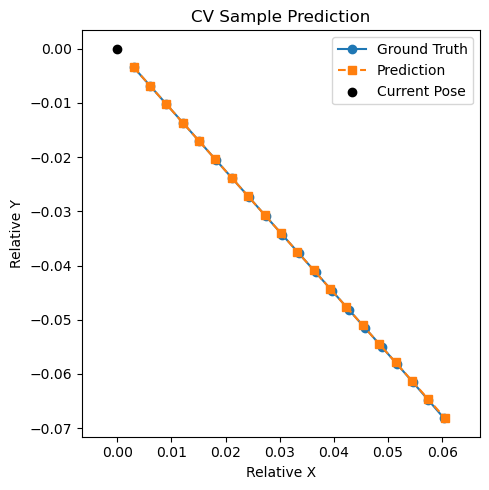

In [7]:
show_sample_plot(cv_pred, cv_target, 'CV Sample Prediction')


## Section: CNN-LSTM

This section trains a single-robot CNN-LSTM on the same split, using only the ego Husky trajectory history (`past_xy`). It ignores graph structure, so it acts as the sequence-only learned baseline in this notebook.


In [8]:
cnn_lstm = CNNLSTM(past_len=PAST_LEN, future_len=FUTURE_LEN).to(DEVICE)
cnn_lstm = train_model(cnn_lstm, train_loader, val_loader, DEVICE, epochs=30, lr=1e-3, use_graph=False)
cnn_pred, cnn_target, cnn_metrics = evaluate_cnn_model(cnn_lstm, test_loader, DEVICE)
cnn_model_path = MODELS_DIR / 'cnn_lstm_graph_done.pt'
torch.save({'model_state': cnn_lstm.state_dict()}, cnn_model_path)
cnn_summary = {
    'model': 'cnn_lstm_graph',
    'samples': len(dataset),
    'train': len(train_set),
    'val': len(val_set),
    'test': len(test_set),
    'ADE': cnn_metrics['ADE'],
    'FDE': cnn_metrics['FDE'],
    'RMSE': cnn_metrics['RMSE'],
    'model_path': str(cnn_model_path.resolve()),
    'past_len': PAST_LEN,
    'future_len': FUTURE_LEN,
}
save_summary(MODELS_DIR / 'summary_cnn_lstm_graph_done.json', cnn_summary)
cnn_metrics


Epoch 01/30 train_loss=0.004266 val_loss=0.000977
Epoch 02/30 train_loss=0.000821 val_loss=0.000572
Epoch 03/30 train_loss=0.000561 val_loss=0.000565
Epoch 04/30 train_loss=0.000407 val_loss=0.000303
Epoch 05/30 train_loss=0.000305 val_loss=0.000246
Epoch 06/30 train_loss=0.000311 val_loss=0.000329
Epoch 07/30 train_loss=0.000303 val_loss=0.000279
Epoch 08/30 train_loss=0.000290 val_loss=0.000275
Epoch 09/30 train_loss=0.000281 val_loss=0.000271
Epoch 10/30 train_loss=0.000276 val_loss=0.000281
Epoch 11/30 train_loss=0.000282 val_loss=0.000284
Epoch 12/30 train_loss=0.000277 val_loss=0.000277
Epoch 13/30 train_loss=0.000268 val_loss=0.000298
Epoch 14/30 train_loss=0.000291 val_loss=0.000251
Epoch 15/30 train_loss=0.000280 val_loss=0.000288
Epoch 16/30 train_loss=0.000273 val_loss=0.000247
Epoch 17/30 train_loss=0.000271 val_loss=0.000239
Epoch 18/30 train_loss=0.000277 val_loss=0.000264
Epoch 19/30 train_loss=0.000274 val_loss=0.000238
Epoch 20/30 train_loss=0.000279 val_loss=0.000262


{'ADE': 0.00775070721283555,
 'FDE': 0.016240214928984642,
 'RMSE': 0.015114538371562958}

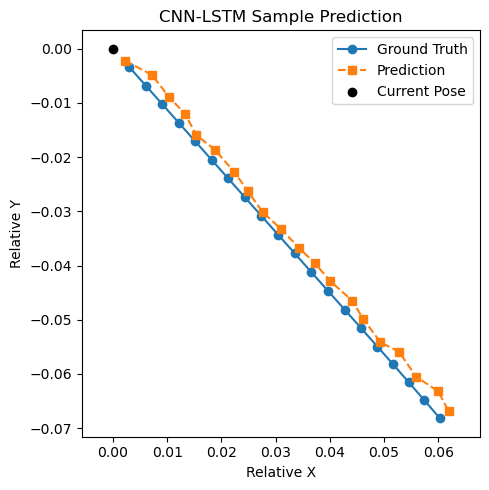

In [9]:
show_sample_plot(cnn_pred, cnn_target, 'CNN-LSTM Sample Prediction')


## Section: GNN-LSTM

This section trains the graph-only temporal model on the same split. It uses graph node and edge features directly, without the extra temporal CNN frontend.


In [10]:
gnn_cfg = {
    'node_dim': 14,
    'edge_dim': 4,
    'hidden_dim': 96,
    'lstm_hidden': 128,
    'lstm_layers': 1,
    'future_len': FUTURE_LEN,
    'ego_idx': 0,
    'msg_passes': 2,
    'dropout': 0.1,
}
gnn_lstm = GNNLSTM(**gnn_cfg).to(DEVICE)
gnn_lstm = train_model(gnn_lstm, train_loader, val_loader, DEVICE, epochs=30, lr=1e-3, use_graph=True)
gnn_pred, gnn_target, gnn_metrics = evaluate_graph_model(gnn_lstm, test_loader, DEVICE)
gnn_model_path = MODELS_DIR / 'gnn_lstm_graph_done_from_notebook.pt'
torch.save({'model_state': gnn_lstm.state_dict(), 'cfg': {**gnn_cfg, 'past_len': PAST_LEN}}, gnn_model_path)
gnn_summary = {
    'model': 'gnn_lstm',
    'samples': len(dataset),
    'train': len(train_set),
    'val': len(val_set),
    'test': len(test_set),
    'comparison': {'constant_velocity': cv_metrics, 'gnn_lstm': gnn_metrics},
    'ADE': gnn_metrics['ADE'],
    'FDE': gnn_metrics['FDE'],
    'RMSE': gnn_metrics['RMSE'],
    'model_path': str(gnn_model_path.resolve()),
    'past_len': PAST_LEN,
    'future_len': FUTURE_LEN,
}
save_summary(MODELS_DIR / 'summary_gnn_graph_done_from_notebook.json', gnn_summary)
gnn_metrics


Epoch 01/30 train_loss=0.004680 val_loss=0.003471
Epoch 02/30 train_loss=0.002711 val_loss=0.000647
Epoch 03/30 train_loss=0.000598 val_loss=0.000576
Epoch 04/30 train_loss=0.000463 val_loss=0.000446
Epoch 05/30 train_loss=0.000404 val_loss=0.000402
Epoch 06/30 train_loss=0.000405 val_loss=0.000314
Epoch 07/30 train_loss=0.000366 val_loss=0.000333
Epoch 08/30 train_loss=0.000350 val_loss=0.000302
Epoch 09/30 train_loss=0.000314 val_loss=0.000256
Epoch 10/30 train_loss=0.000307 val_loss=0.000254
Epoch 11/30 train_loss=0.000301 val_loss=0.000267
Epoch 12/30 train_loss=0.000307 val_loss=0.000314
Epoch 13/30 train_loss=0.000284 val_loss=0.000261
Epoch 14/30 train_loss=0.000281 val_loss=0.000263
Epoch 15/30 train_loss=0.000294 val_loss=0.000307
Epoch 16/30 train_loss=0.000276 val_loss=0.000224
Epoch 17/30 train_loss=0.000271 val_loss=0.000246
Epoch 18/30 train_loss=0.000302 val_loss=0.000275
Epoch 19/30 train_loss=0.000255 val_loss=0.000249
Epoch 20/30 train_loss=0.000270 val_loss=0.000275


{'ADE': 0.010440986603498459,
 'FDE': 0.019013741984963417,
 'RMSE': 0.015159054659307003}

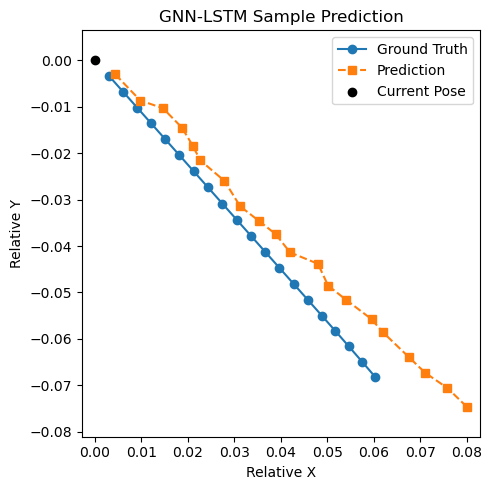

In [11]:
show_sample_plot(gnn_pred, gnn_target, 'GNN-LSTM Sample Prediction')


## Section: CNN-GNN-LSTM

This section trains the hybrid model. A temporal CNN first compresses node histories, then a GNN models multi-agent interaction, and an LSTM predicts future motion.


In [12]:
cnn_gnn_cfg = {
    'node_dim': 14,
    'edge_dim': 4,
    'cnn_hidden': 64,
    'graph_hidden': 96,
    'lstm_hidden': 128,
    'lstm_layers': 1,
    'future_len': FUTURE_LEN,
    'ego_idx': 0,
    'msg_passes': 2,
    'dropout': 0.1,
}
cnn_gnn_lstm = CNNGNNLSTM(**cnn_gnn_cfg).to(DEVICE)
cnn_gnn_lstm = train_model(cnn_gnn_lstm, train_loader, val_loader, DEVICE, epochs=30, lr=1e-3, use_graph=True)
cnn_gnn_pred, cnn_gnn_target, cnn_gnn_metrics = evaluate_graph_model(cnn_gnn_lstm, test_loader, DEVICE)
cnn_gnn_model_path = MODELS_DIR / 'cnn_gnn_lstm_graph_done_from_notebook.pt'
torch.save({'model_state': cnn_gnn_lstm.state_dict(), 'cfg': {**cnn_gnn_cfg, 'past_len': PAST_LEN}}, cnn_gnn_model_path)
cnn_gnn_summary = {
    'model': 'cnn_gnn_lstm',
    'samples': len(dataset),
    'train': len(train_set),
    'val': len(val_set),
    'test': len(test_set),
    'comparison': {'constant_velocity': cv_metrics, 'cnn_gnn_lstm': cnn_gnn_metrics},
    'ADE': cnn_gnn_metrics['ADE'],
    'FDE': cnn_gnn_metrics['FDE'],
    'RMSE': cnn_gnn_metrics['RMSE'],
    'model_path': str(cnn_gnn_model_path.resolve()),
    'past_len': PAST_LEN,
    'future_len': FUTURE_LEN,
}
save_summary(MODELS_DIR / 'summary_cnn_gnn_graph_done_from_notebook.json', cnn_gnn_summary)
cnn_gnn_metrics


Epoch 01/30 train_loss=0.004714 val_loss=0.003694
Epoch 02/30 train_loss=0.003441 val_loss=0.002149
Epoch 03/30 train_loss=0.000801 val_loss=0.000535
Epoch 04/30 train_loss=0.000443 val_loss=0.000478
Epoch 05/30 train_loss=0.000415 val_loss=0.000409
Epoch 06/30 train_loss=0.000349 val_loss=0.000315
Epoch 07/30 train_loss=0.000343 val_loss=0.000324
Epoch 08/30 train_loss=0.000342 val_loss=0.000299
Epoch 09/30 train_loss=0.000306 val_loss=0.000313
Epoch 10/30 train_loss=0.000321 val_loss=0.000274
Epoch 11/30 train_loss=0.000305 val_loss=0.000266
Epoch 12/30 train_loss=0.000295 val_loss=0.000253
Epoch 13/30 train_loss=0.000264 val_loss=0.000287
Epoch 14/30 train_loss=0.000268 val_loss=0.000352
Epoch 15/30 train_loss=0.000276 val_loss=0.000290
Epoch 16/30 train_loss=0.000264 val_loss=0.000236
Epoch 17/30 train_loss=0.000253 val_loss=0.000210
Epoch 18/30 train_loss=0.000231 val_loss=0.000245
Epoch 19/30 train_loss=0.000239 val_loss=0.000225
Epoch 20/30 train_loss=0.000244 val_loss=0.000245


{'ADE': 0.008119557052850723,
 'FDE': 0.015822038054466248,
 'RMSE': 0.014050591737031937}

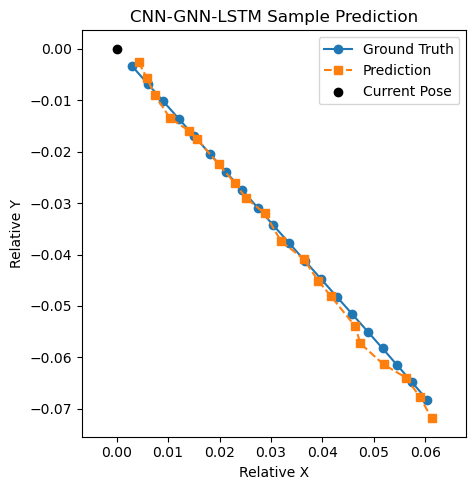

In [13]:
show_sample_plot(cnn_gnn_pred, cnn_gnn_target, 'CNN-GNN-LSTM Sample Prediction')


## Save A Unified Comparison Table

This section combines the four model results into one saved table so the experiment can be reused in reports, thesis figures, or later analysis.


In [14]:
comparison_rows = [
    {'Model': 'Constant Velocity', **cv_metrics},
    {'Model': 'CNN-LSTM', **cnn_metrics},
    {'Model': 'GNN-LSTM', **gnn_metrics},
    {'Model': 'CNN-GNN-LSTM', **cnn_gnn_metrics},
]

comparison_json = MODELS_DIR / 'summary_model_comparison_from_notebook.json'
comparison_csv = MODELS_DIR / 'summary_model_comparison_from_notebook.csv'
comparison_json.write_text(json.dumps(comparison_rows, indent=2))
with comparison_csv.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['Model', 'ADE', 'FDE', 'RMSE'])
    writer.writeheader()
    writer.writerows(comparison_rows)

comparison_rows


[{'Model': 'Constant Velocity',
  'ADE': 0.004881541710346937,
  'FDE': 0.012086867354810238,
  'RMSE': 0.015232838690280914},
 {'Model': 'CNN-LSTM',
  'ADE': 0.00775070721283555,
  'FDE': 0.016240214928984642,
  'RMSE': 0.015114538371562958},
 {'Model': 'GNN-LSTM',
  'ADE': 0.010440986603498459,
  'FDE': 0.019013741984963417,
  'RMSE': 0.015159054659307003},
 {'Model': 'CNN-GNN-LSTM',
  'ADE': 0.008119557052850723,
  'FDE': 0.015822038054466248,
  'RMSE': 0.014050591737031937}]

## Results Table

Lower values are better for ADE, FDE, and RMSE. This gives a compact numerical summary before we move to visualizations.


In [15]:
print(f"{'Model':<18} {'ADE':>12} {'FDE':>12} {'RMSE':>12}")
print('-' * 58)
for row in comparison_rows:
    print(f"{row['Model']:<18} {row['ADE']:>12.6f} {row['FDE']:>12.6f} {row['RMSE']:>12.6f}")


Model                       ADE          FDE         RMSE
----------------------------------------------------------
Constant Velocity      0.004882     0.012087     0.015233
CNN-LSTM               0.007751     0.016240     0.015115
GNN-LSTM               0.010441     0.019014     0.015159
CNN-GNN-LSTM           0.008120     0.015822     0.014051


## Mixed Visualization: Grouped Metric Plot

This grouped bar chart compares all four models on the same figure so differences across ADE, FDE, and RMSE are visible at a glance.


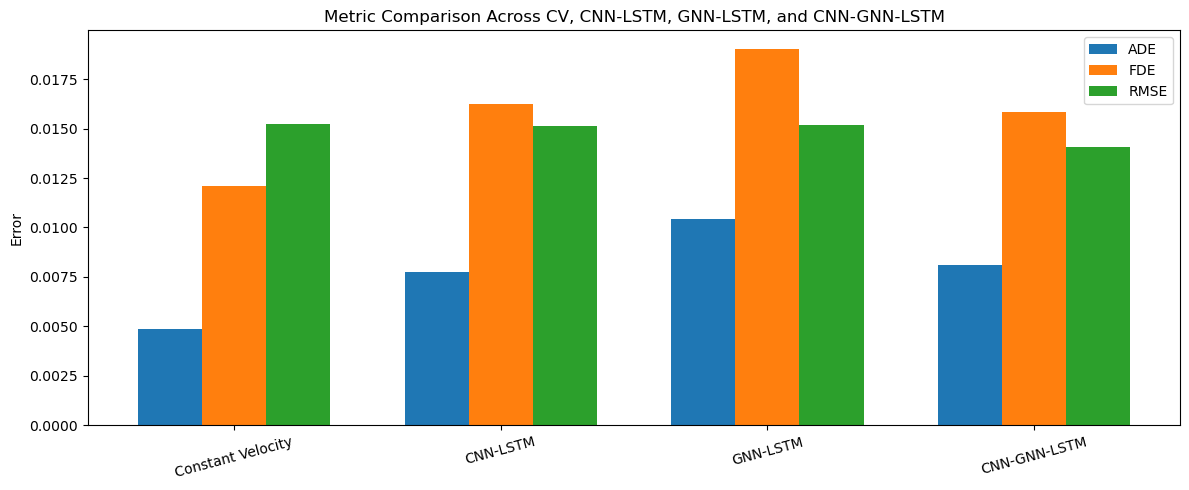

In [16]:
model_names = [row['Model'] for row in comparison_rows]
ade_vals = [row['ADE'] for row in comparison_rows]
fde_vals = [row['FDE'] for row in comparison_rows]
rmse_vals = [row['RMSE'] for row in comparison_rows]

x = range(len(model_names))
width = 0.24

plt.figure(figsize=(12, 5))
plt.bar([i - width for i in x], ade_vals, width=width, label='ADE')
plt.bar(x, fde_vals, width=width, label='FDE')
plt.bar([i + width for i in x], rmse_vals, width=width, label='RMSE')
plt.xticks(list(x), model_names, rotation=15)
plt.ylabel('Error')
plt.title('Metric Comparison Across CV, CNN-LSTM, GNN-LSTM, and CNN-GNN-LSTM')
plt.legend()
plt.tight_layout()
plt.show()


## Mixed Visualization: Per-Metric Plots

These separate plots make it easier to inspect small differences in one metric at a time.


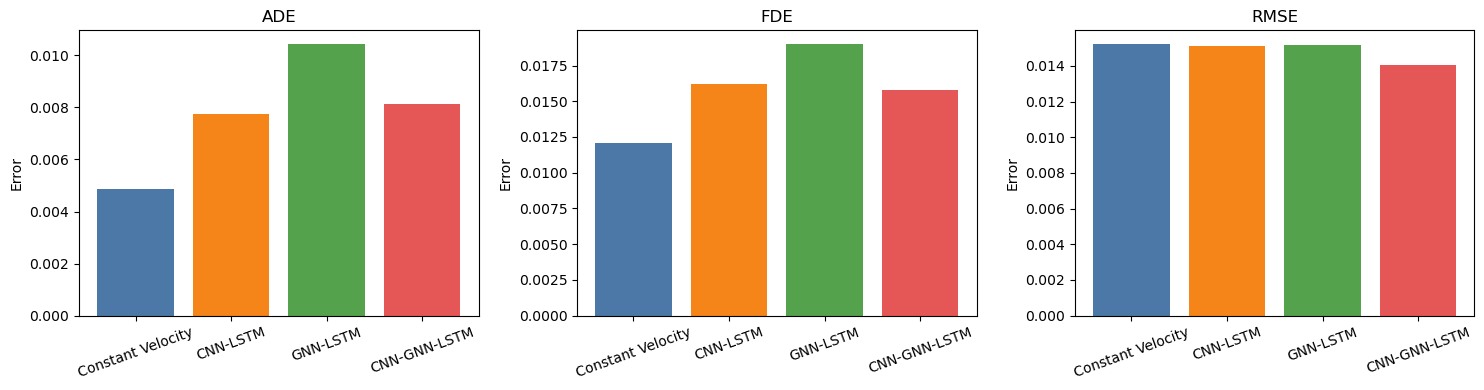

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('ADE', ade_vals), ('FDE', fde_vals), ('RMSE', rmse_vals)]
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']

for ax, (label, values) in zip(axes, metrics):
    ax.bar(model_names, values, color=colors)
    ax.set_title(label)
    ax.set_ylabel('Error')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## Mixed Visualization: Sample Overlay

This final plot overlays one sample prediction from each model against the same ground-truth future trajectory so the qualitative differences are easy to inspect.


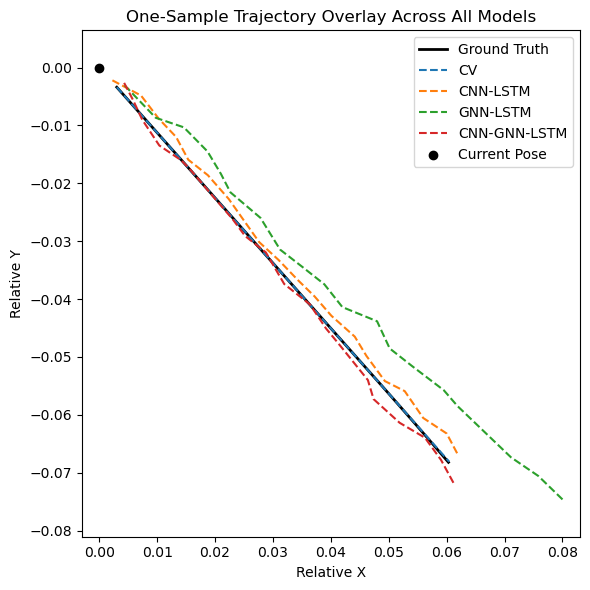

In [18]:
sample_idx = 0
true_np = cv_target[sample_idx].numpy()
plt.figure(figsize=(6, 6))
plt.plot(true_np[:, 0], true_np[:, 1], 'k-', linewidth=2, label='Ground Truth')
plt.plot(cv_pred[sample_idx][:, 0], cv_pred[sample_idx][:, 1], '--', label='CV')
plt.plot(cnn_pred[sample_idx][:, 0], cnn_pred[sample_idx][:, 1], '--', label='CNN-LSTM')
plt.plot(gnn_pred[sample_idx][:, 0], gnn_pred[sample_idx][:, 1], '--', label='GNN-LSTM')
plt.plot(cnn_gnn_pred[sample_idx][:, 0], cnn_gnn_pred[sample_idx][:, 1], '--', label='CNN-GNN-LSTM')
plt.scatter([0], [0], c='black', label='Current Pose')
plt.title('One-Sample Trajectory Overlay Across All Models')
plt.xlabel('Relative X')
plt.ylabel('Relative Y')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()
